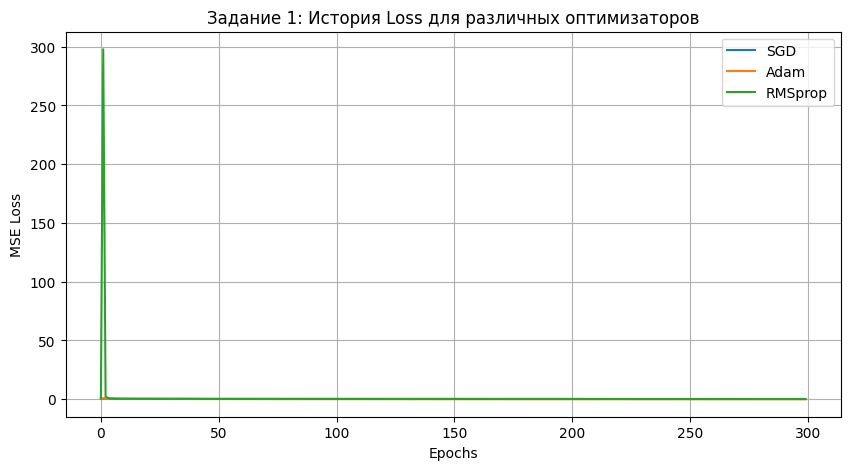

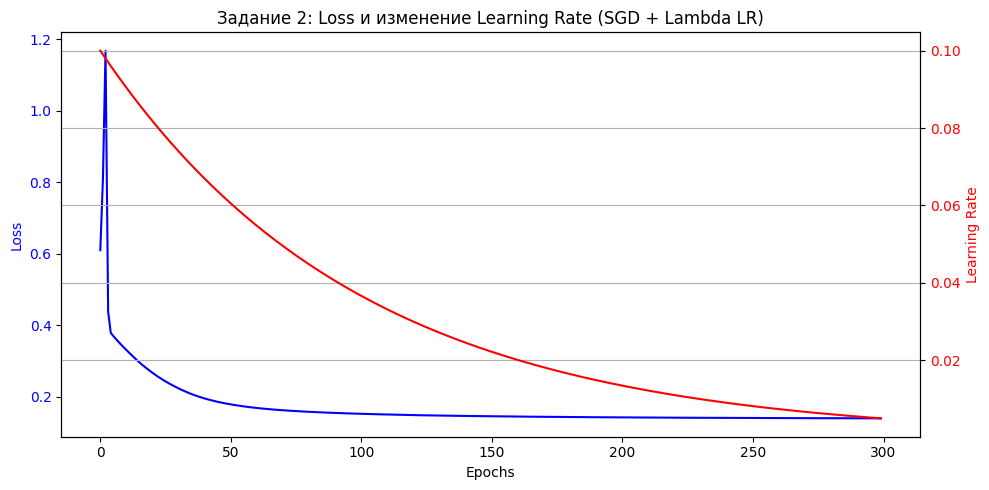

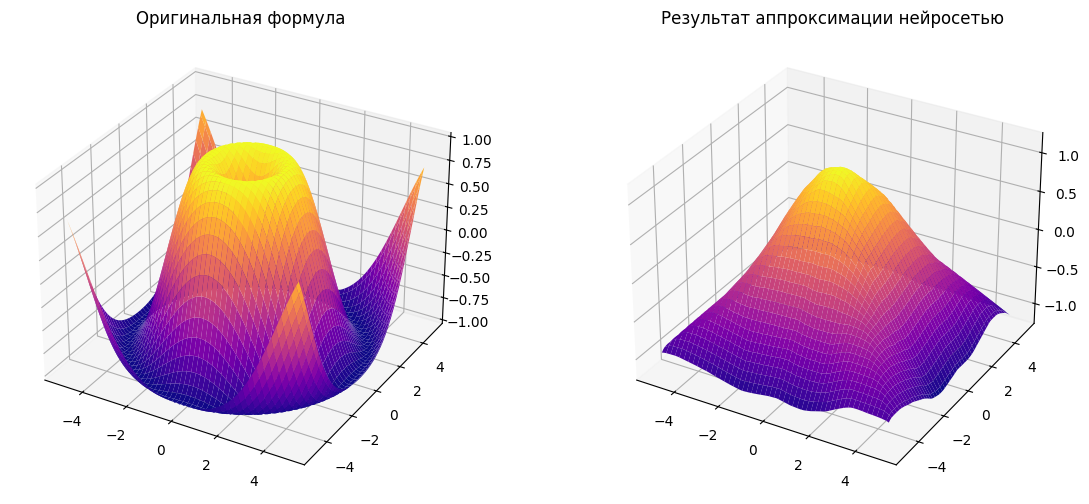

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

k_val = 1.0
X = torch.rand(2500, 2) * 10 - 5
y = torch.sin(k_val * torch.sqrt(X[:, 0]**2 + X[:, 1]**2)).unsqueeze(1)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

epochs = 300
criterion = nn.MSELoss()

optimizers_dict = {
    'SGD': lambda params: optim.SGD(params, lr=0.01),
    'Adam': lambda params: optim.Adam(params, lr=0.01),
    'RMSprop': lambda params: optim.RMSprop(params, lr=0.01)
}

losses_history = {}

for opt_name, get_opt in optimizers_dict.items():
    model = SimpleNet()
    optimizer = get_opt(model.parameters())
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X)
        loss = criterion(predictions, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    losses_history[opt_name] = losses

plt.figure(figsize=(10, 5))
for opt_name, losses in losses_history.items():
    plt.plot(losses, label=opt_name)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Задание 1: История Loss для различных оптимизаторов')
plt.legend()
plt.grid(True)
plt.show()

model_lambda = SimpleNet()
optimizer_lambda = optim.SGD(model_lambda.parameters(), lr=0.1)

lambda_lr = lambda epoch: 0.99 ** epoch
scheduler = optim.lr_scheduler.LambdaLR(optimizer_lambda, lr_lambda=lambda_lr)

loss_history_task2 = []
lr_history = []

for epoch in range(epochs):
    optimizer_lambda.zero_grad()
    predictions = model_lambda(X)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer_lambda.step()

    loss_history_task2.append(loss.item())
    lr_history.append(optimizer_lambda.param_groups[0]['lr'])

    scheduler.step()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(loss_history_task2, 'b-', label='MSE Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(lr_history, 'r-', label='Learning Rate')
ax2.set_ylabel('Learning Rate', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Задание 2: Loss и изменение Learning Rate (SGD + Lambda LR)')
fig.tight_layout()
plt.grid(True)
plt.show()




import numpy as np

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X_grid, Y_grid = np.meshgrid(x, y)

Z_true = np.sin(k_val * np.sqrt(X_grid**2 + Y_grid**2))

grid_points = np.c_[X_grid.ravel(), Y_grid.ravel()]
grid_tensor = torch.FloatTensor(grid_points)

with torch.no_grad():
    Z_pred = model_lambda(grid_tensor).numpy().reshape(X_grid.shape)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X_grid, Y_grid, Z_true, cmap='plasma')
ax1.set_title('Оригинальная формула')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X_grid, Y_grid, Z_pred, cmap='plasma')
ax2.set_title('Результат аппроксимации нейросетью')

plt.show()